# Final Visualizations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

fp_naive = "data/output_data/naive_allocation.csv"
fp_informed = "data/output_data/informed_allocation.csv"
fp_delta = "data/output_data/allocation_delta.csv"

naive_table = pd.read_csv(fp_naive)
informed_table = pd.read_csv(fp_informed)
delta_table = pd.read_csv(fp_delta)

## Generate Viz

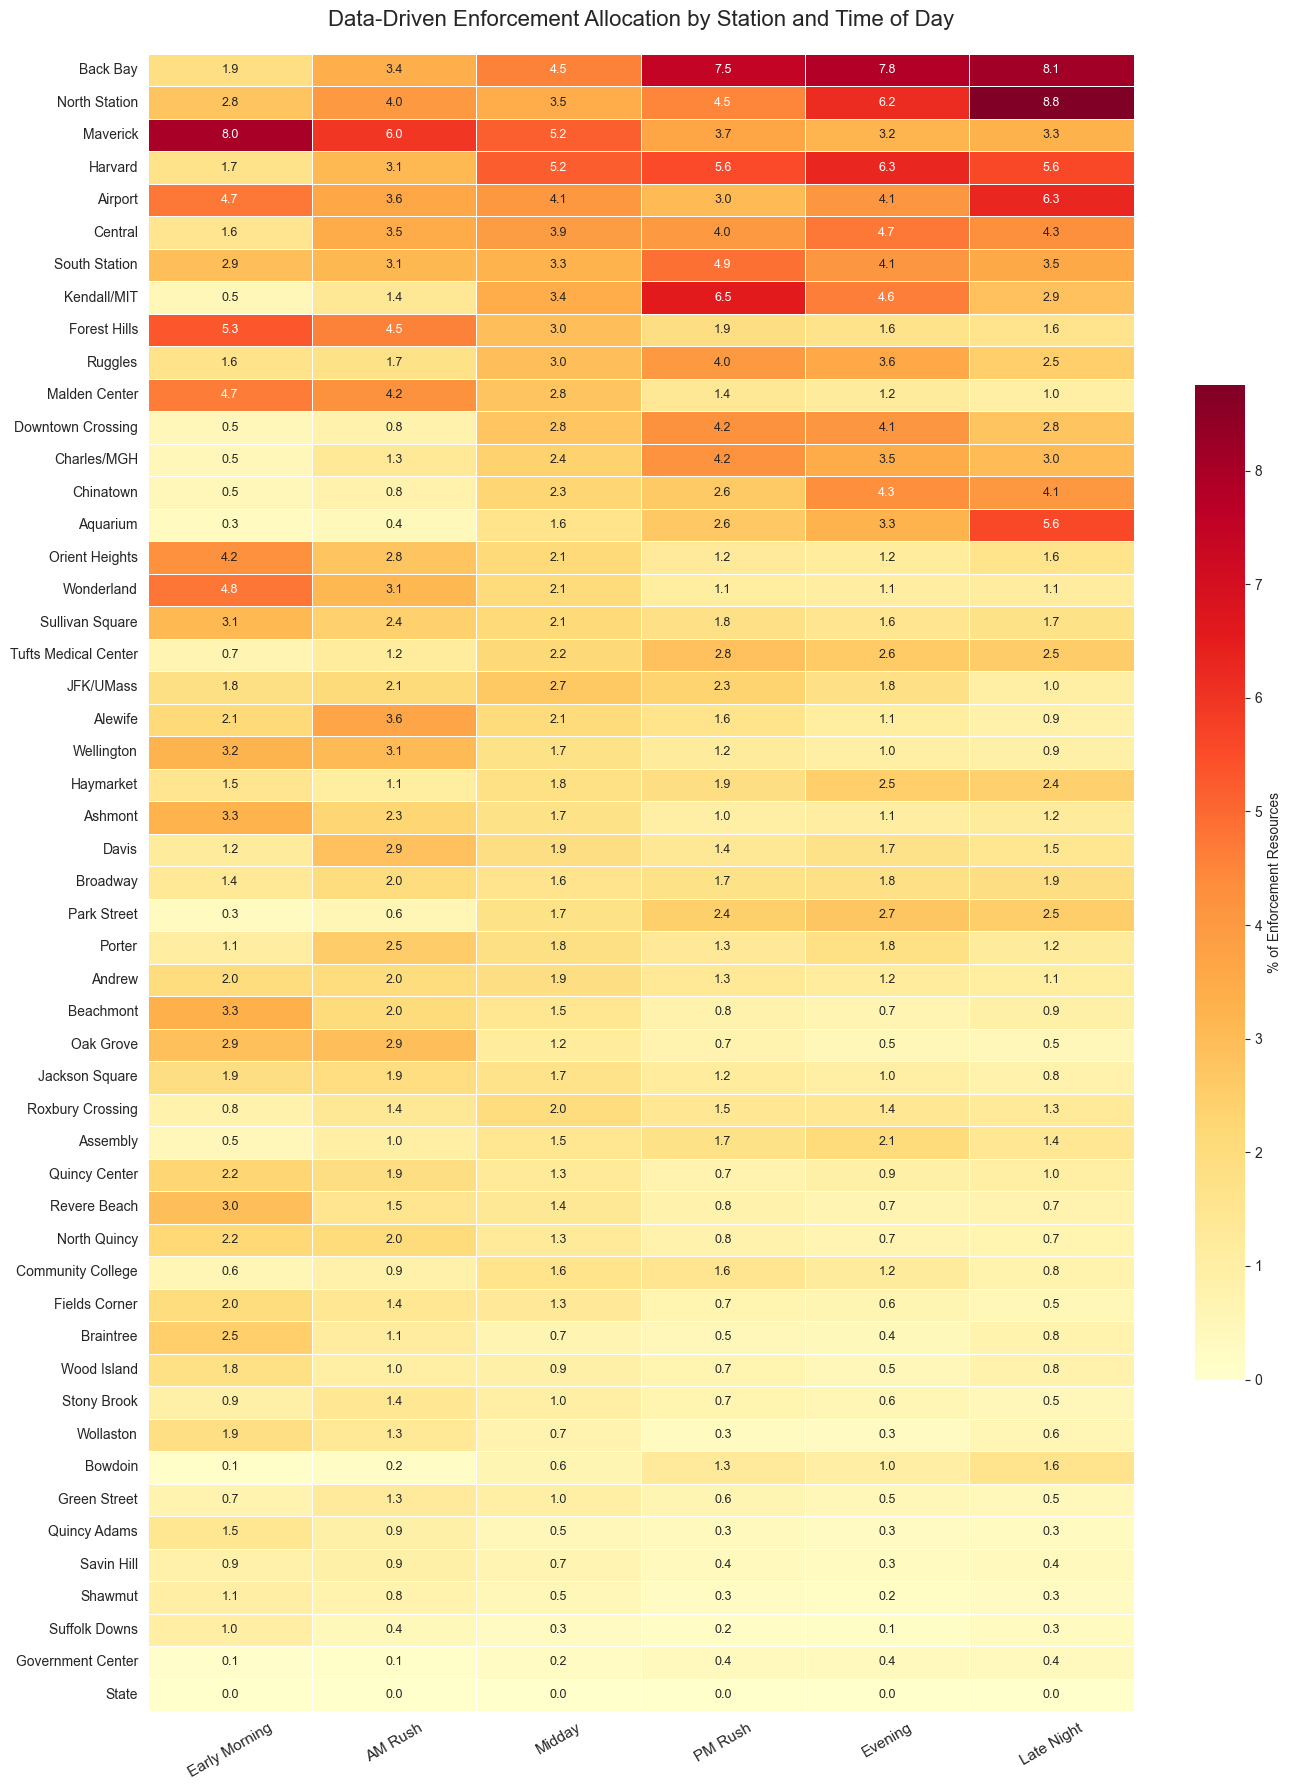

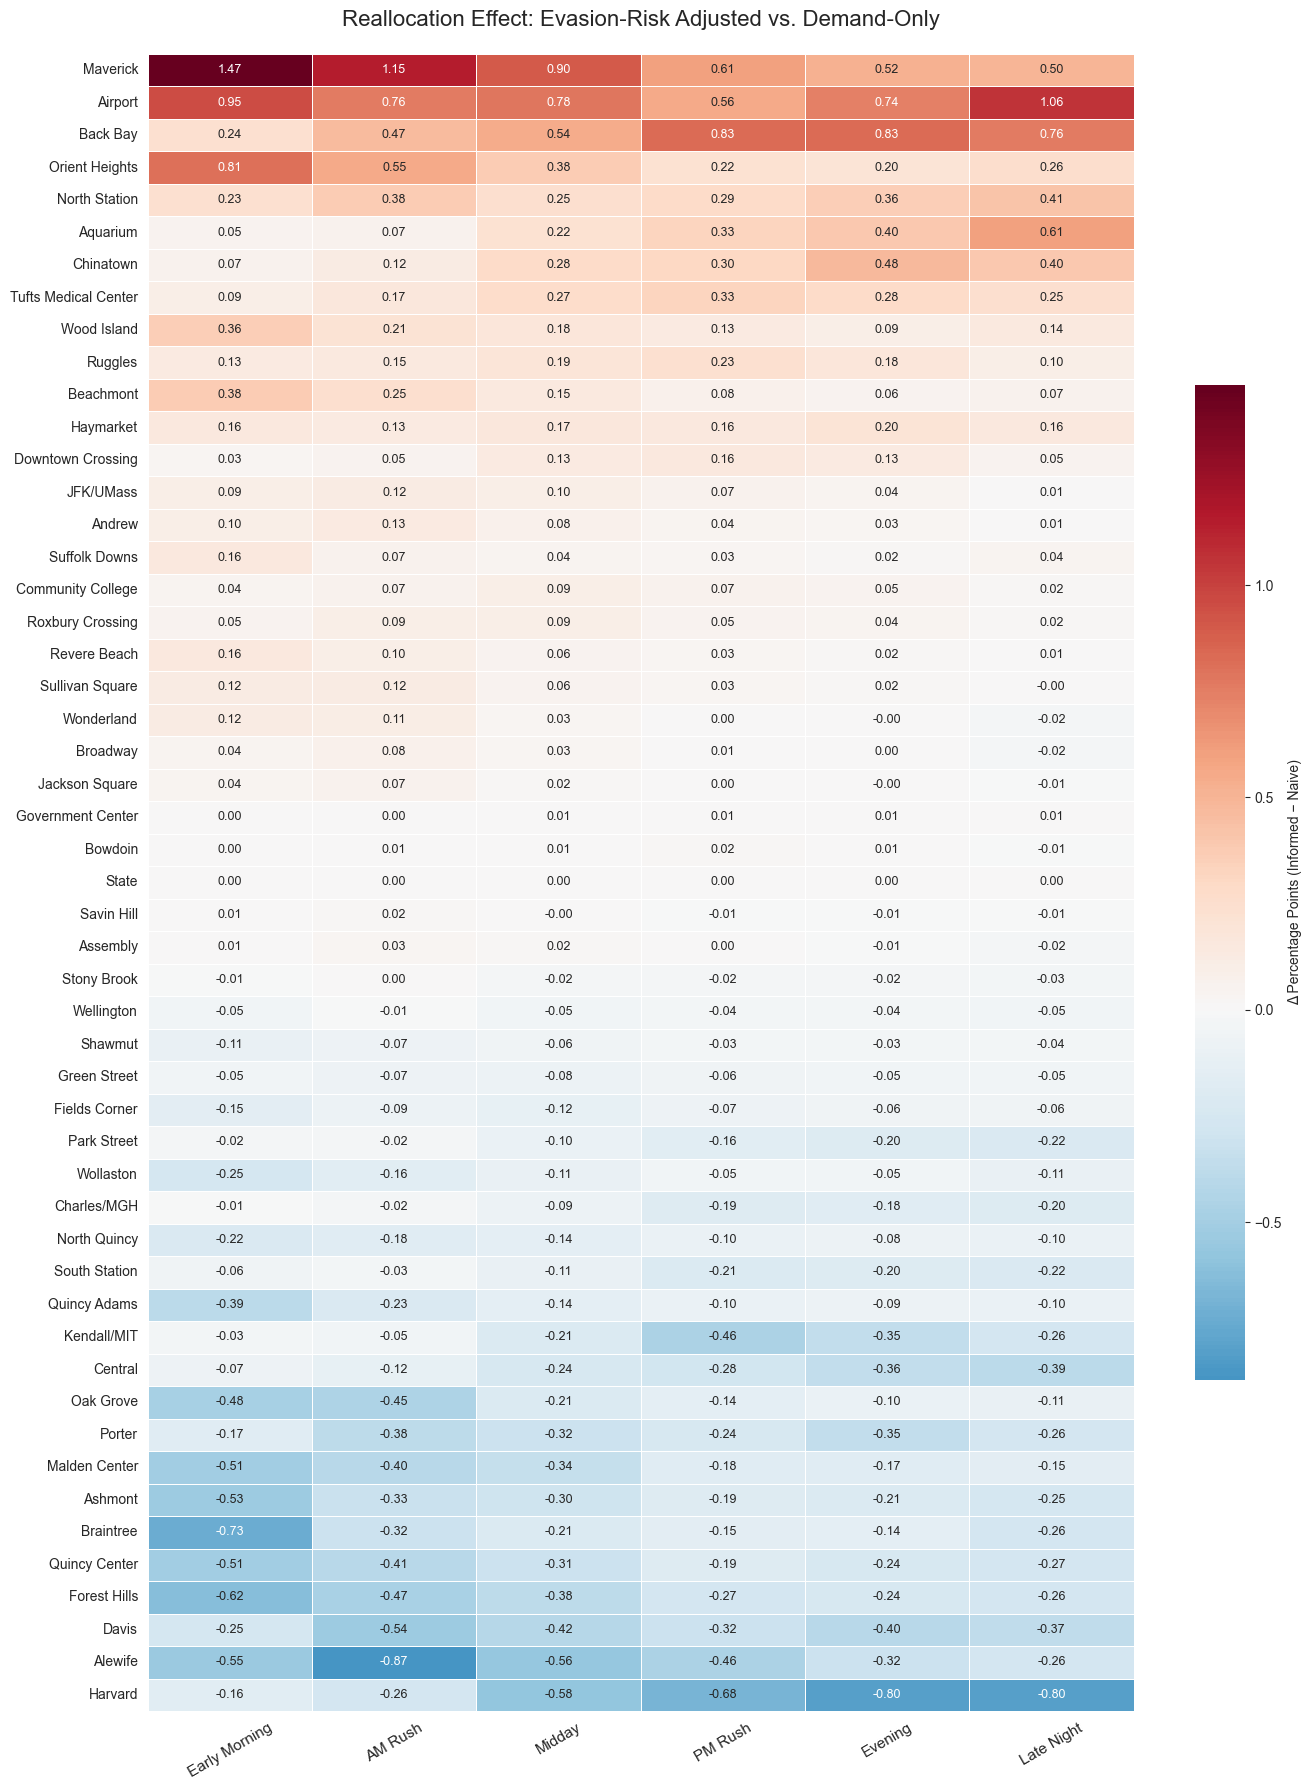

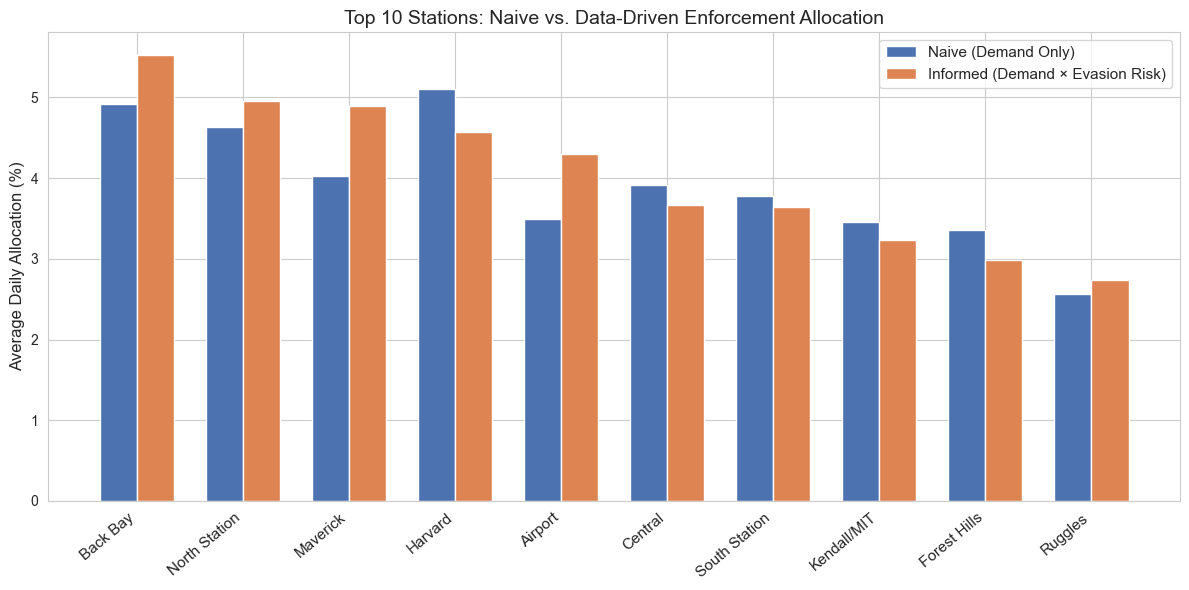

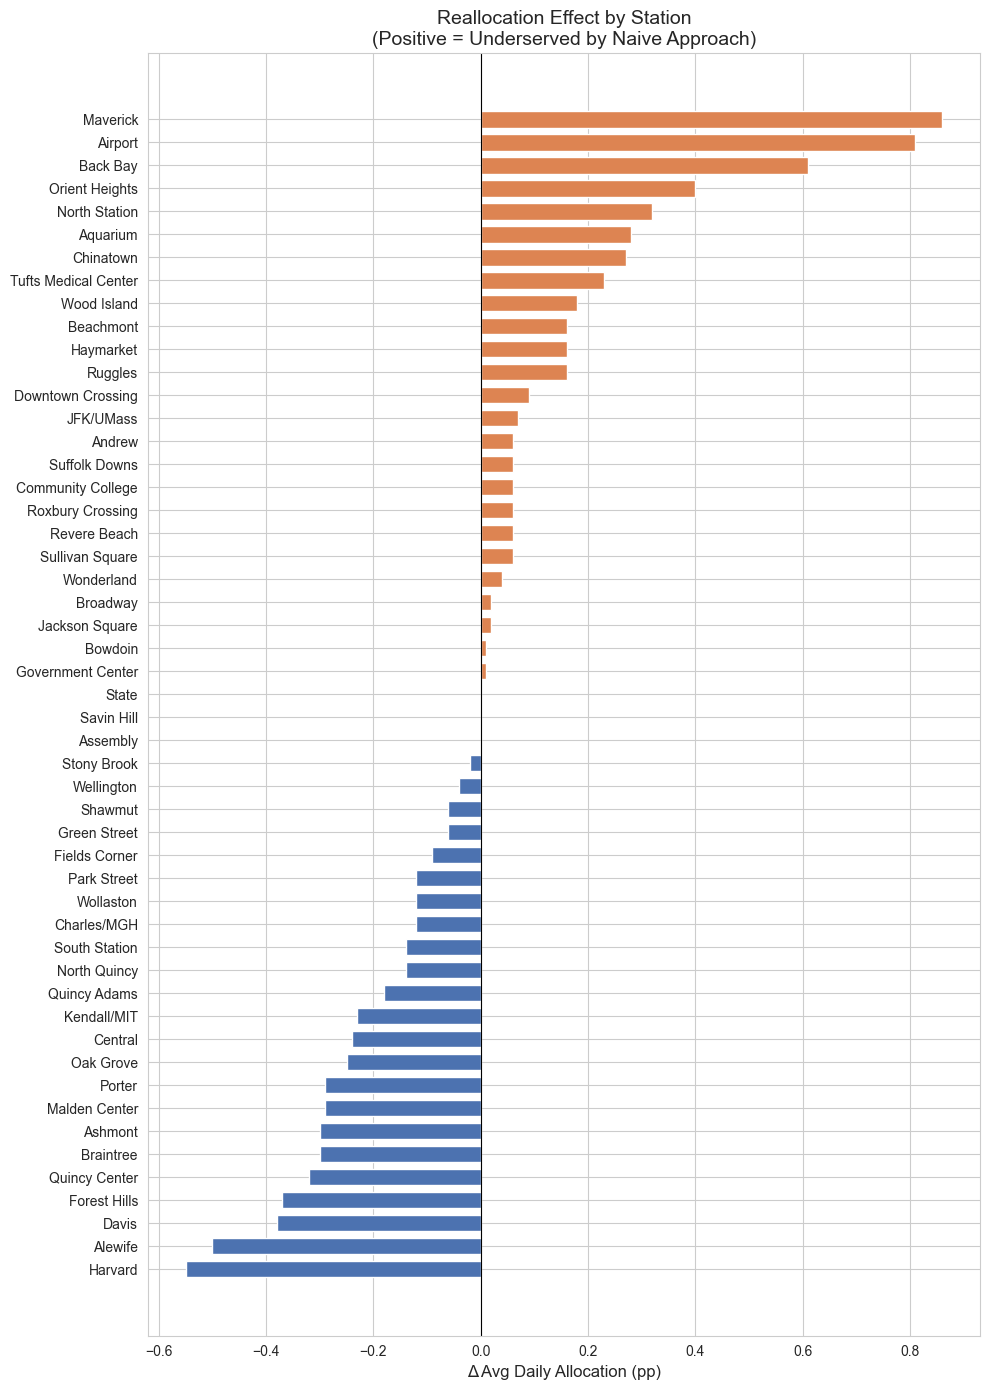

In [ ]:
sns.set_style("whitegrid")
time_order = ["Early Morning", "AM Rush", "Midday", "PM Rush", "Evening", "Late Night"]

# --- 1. Heatmap: Informed Allocation ---
fig, ax = plt.subplots(figsize=(14, 18))
sns.heatmap(
    informed_table.set_index("source_station")[time_order],
    cmap="YlOrRd",
    annot=True, fmt=".1f", annot_kws={"size": 9},
    linewidths=0.5,
    cbar_kws={"label": "% of Enforcement Resources", "shrink": 0.6},
    ax=ax
)
ax.set_title("Data-Driven Enforcement Allocation by Station and Time of Day", fontsize=16, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=11, rotation=30)
plt.tight_layout()
plt.savefig("assets/heatmap_informed.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2. Heatmap: Delta (Informed - Naive) ---
fig, ax = plt.subplots(figsize=(14, 18))
sns.heatmap(
    delta_table.set_index("source_station")[time_order],
    cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.5,
    cbar_kws={"label": "Δ Percentage Points (Informed − Naive)", "shrink": 0.6},
    ax=ax
)
ax.set_title("Reallocation Effect: Evasion-Risk Adjusted vs. Demand-Only", fontsize=16, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=11, rotation=30)
plt.tight_layout()
plt.savefig("assets/heatmap_delta.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 3. Top 10 Stations: Naive vs Informed (grouped bar) ---
top10 = informed_table.set_index("source_station")["daily_avg"].head(10)
top10_naive = naive_table.set_index("source_station").loc[top10.index, "daily_avg"]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top10))
width = 0.35
ax.bar([i - width/2 for i in x], top10_naive, width, label="Naive (Demand Only)", color="#4C72B0")
ax.bar([i + width/2 for i in x], top10, width, label="Informed (Demand × Evasion Risk)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(top10.index, rotation=40, ha="right", fontsize=11)
ax.set_ylabel("Average Daily Allocation (%)", fontsize=12)
ax.set_title("Top 10 Stations: Naive vs. Data-Driven Enforcement Allocation", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("assets/bar_top10_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 4. Delta distribution ---
fig, ax = plt.subplots(figsize=(10, 14))
delta_vals = delta_table.set_index("source_station")["avg_delta"].sort_values()
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in delta_vals]
ax.barh(delta_vals.index, delta_vals, color=colors, height=0.7)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Δ Avg Daily Allocation (pp)", fontsize=12)
ax.set_title("Reallocation Effect by Station\n(Positive = Underserved by Naive Approach)", fontsize=14)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig("assets/bar_delta_all.png", dpi=300, bbox_inches="tight")
plt.show()